(sec:sklearn)=
# Scikit-Learn

[Scikit-Learn](https://scikit-learn.org/stable/) is a machine learning library based on Numpy, Scipy and Matplotlib. It stands out with its simple and easy to use syntax, setting defaults, which make it very beginner friendly, while also providing a wide spectrum of tools and the scalability required to make it applicable beyond basic custom test cases, by providing wrappers to other libraries.

You can setup various different models with just a single line of code. For instance a neural network can be instantiated as

In [1]:
from sklearn.neural_network import MLPClassifier

NN = MLPClassifier(hidden_layer_sizes=(5, 3))

Provided some data, training also requires only one line of code and assessment of the accuracy is just as user friendly.

In [2]:
import warnings

warnings.filterwarnings("ignore")  # With random data the optimization won't converge

In [3]:
import numpy as np

# Providing some random data
X_train = np.random.rand(20, 10)
y_train = np.random.choice(3, 20)

# Train the model
NN.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(5, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",None


## Available models

In order to make an educated choice for the model to be applied, it helps to understand the structure of the data at hand. This is, however, a rather vague statement, which should encourage you to play around with models sometimes. 

There are three basic approaches, depending on the type of data, namely [supervised, unsupervised and reinforcement learning](https://en.wikipedia.org/wiki/Machine_learning#Approaches). 

For the actual model, one can pick from a vast zoo, with common ones being

- [Neural Network (NN)](https://en.wikipedia.org/wiki/Neural_network_(machine_learning))
- [Support Vector Machine (SVM)](https://en.wikipedia.org/wiki/Support_vector_machine)
- [Decision Tree models, especially Random Forest](https://en.wikipedia.org/wiki/Random_forest)
- [Naive Bayes (NB)](https://en.wikipedia.org/wiki/Naive_Bayes_classifier)
- [Linear Regression](https://en.wikipedia.org/wiki/Regression_analysis#Linear_regression)
- [K-Nearest Neighbors (KNN)](https://en.wikipedia.org/wiki/K-nearest_neighbors_algorithm)

## Example: Recognition of handwritten numbers

This tutorial uses [scikit-learn](https://scikit-learn.org/stable/) (or sklearn), an open source machine learning (ML) framework based on numpy, scipy and matplotlib.

In [5]:
import matplotlib.pyplot as plt

# Import datasets, classifiers and performance metrics
from sklearn import datasets, metrics, svm
from sklearn.model_selection import train_test_split

A widely used example for the use of machine learning is the recognition of handwritten numbers, for which we will build, train and assess the accuracy of a machine learning model. The example is so common in fact that sklearn, like many other ML frameworks, come with a built-in data set of handwritten numbers.

In [6]:
# Loading a data set containing 1797 8 x 8 images of digits
digits = datasets.load_digits()

print(type(digits.images))
print(digits.images.shape)

<class 'numpy.ndarray'>
(1797, 8, 8)


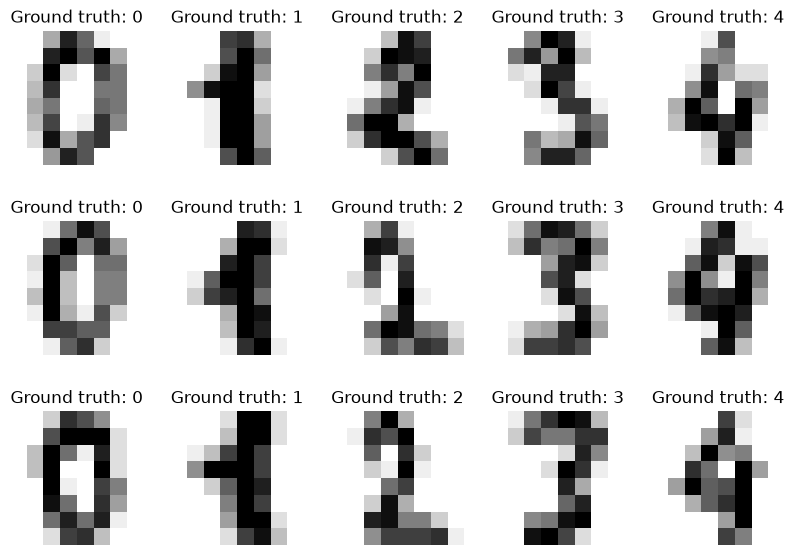

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(10, 7))
for i, row in enumerate(axes):
    for j, ax in enumerate(row):
        ax.set_axis_off()
        ax.imshow(
            digits.images[i * 10 + j], cmap=plt.cm.gray_r, interpolation="nearest"
        )
        ax.set_title(f"Ground truth: {digits.target[i * 10 + j]}")

### Splitting the dataset

For ML applications the data is always split in at least two datasets, since for proper evaluation of the performance of the trained model unseen data is required. Whether additional separation of the data set is required depends on the ML model applied, as well as the optimization algorithm.

In [8]:
# Flatten the images
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

# Split data into 80% train and 20% test subsets, which is a standard ratio
X_train, X_test, y_train, y_test = train_test_split(
    data, digits.target, test_size=0.2, shuffle=True
)

### Pick the model

With a rather modest amount of annotated data at hand to solve a classification type problem, it makes sense to use an SVM, since they can make use of different kernels, projecting lower dimensional parameter spaces into higher dimensional ones and therefore saving a lot on the parameters to fit. NNs are more flexible in their basic form, which comes with the price of more parameters.

In [9]:
# Create SVM classifier with a radial basis function (RBF) kernel
my_classifier = svm.SVC(gamma=0.001)

### Train the model

In [10]:
# Train the model on the train subset
my_classifier.fit(X_train, y_train)

# Remember to save your model to a file, if you want to use it again!!!
# This can be achieved e.g. by pickling my_classifier
# import pickle

# save
# with open('my_model.pkl','wb') as f:
#    pickle.dump(my_classifier,f)

# load
# with open('my_model.pkl', 'rb') as f:
#    my_classifier = pickle.load(f)

,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### Assess the accuracy

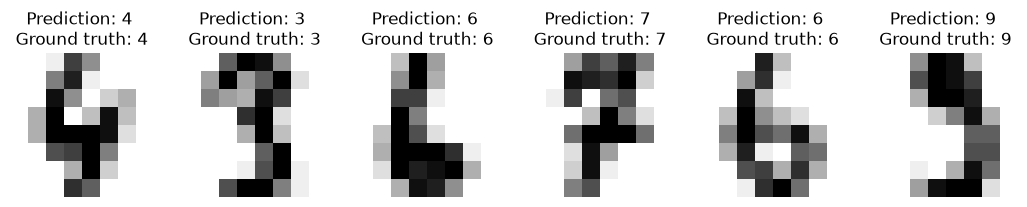

In [11]:
# Predict the value of the digit on the test subset
predicted = my_classifier.predict(X_test)

# Plot some predictions
fig, axes = plt.subplots(nrows=1, ncols=6, figsize=(13, 3))
for ax, image, prediction, GroundTruth in zip(axes, X_test, predicted, y_test):
    ax.set_axis_off()
    image = image.reshape(8, 8)
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title(f"Prediction: {prediction} \nGround truth: {GroundTruth}")

In [12]:
# Show how the classifier performs for the individual numbers
print(
    f"Classification report for classifier {my_classifier}:\n"
    f"{metrics.classification_report(y_test, predicted)}\n"
)

Classification report for classifier SVC(gamma=0.001):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       0.94      1.00      0.97        30
           2       1.00      1.00      1.00        34
           3       1.00      1.00      1.00        38
           4       1.00      0.95      0.97        38
           5       0.97      1.00      0.99        33
           6       1.00      1.00      1.00        39
           7       1.00      1.00      1.00        37
           8       0.97      0.94      0.96        36
           9       0.97      0.97      0.97        34

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360




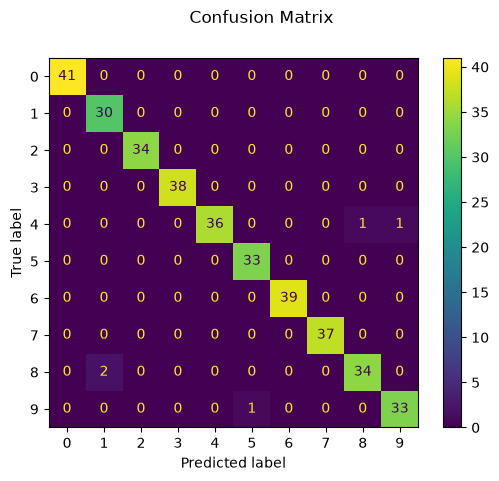

In [13]:
# Show confusion matrix
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, predicted)
disp.figure_.suptitle("Confusion Matrix")
# uncomment to show it as 2D array
# print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()

In [14]:
# amount of coefficients to be fitted for the SVM used here
# 45 * 8 * 8 + 45
print(
    f"The amount of coefficients used by the SVM model are "
    f"{np.prod(my_classifier._get_coef().shape) + len(my_classifier.intercept_)}"
)

# amount of coefficients to be fitted for the NN from the previous notebook
# bias of first layer 28 * 28, hidden layer 512, and output layer 10
# connections 28 * 28 * 512 + 512 * 10
print(
    f"The amount of coefficients used by the NN model of the previous "
    f"notebook are {28 * 28 + 512 + 10 + 28 * 28 * 512 + 512 * 10}"
)
# adapted to the problem at hand with 8 x 8 images
print(
    f"The amount of coefficients used by an NN model for this problem inspired "
    f"by the previous notebook are {8 * 8 + 512 + 10 + 8 * 8 * 512 + 512 * 10}"
)

The amount of coefficients used by the SVM model are 2925
The amount of coefficients used by the NN model of the previous notebook are 407834
The amount of coefficients used by an NN model for this problem inspired by the previous notebook are 38474


The SVM has an accuracy of 0.9861111111111112, while the NN has an accuracy of 0.9611111111111111


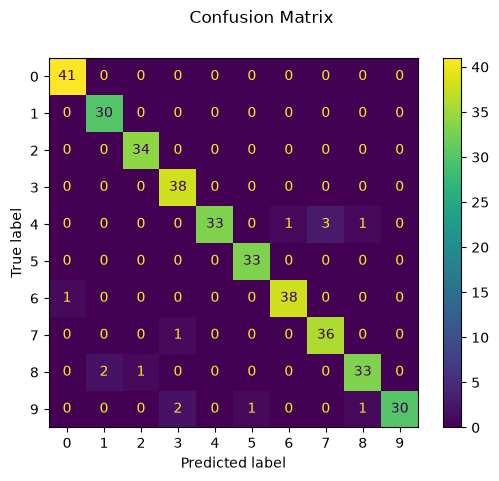

In [15]:
# build a NN with similar amount of parameters than SVM and compare performance
from sklearn.neural_network import MLPClassifier

my_nn_classifier = MLPClassifier(hidden_layer_sizes=(45))
my_nn_classifier.fit(X_train, y_train)
my_nn_prediction = my_nn_classifier.predict(X_test)

print(
    f"The SVM has an accuracy of {metrics.accuracy_score(y_test, predicted)}, "
    f"while the NN has an accuracy of {metrics.accuracy_score(y_test, my_nn_prediction)}"
)

nn_disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, my_nn_prediction)
nn_disp.figure_.suptitle("Confusion Matrix")
plt.show()

As can be seen the overall accuracy is very good, with the confusion matrix showing which numbers have been confused with each other how often.
It is also interesting to see how the model performance improved over the training iterations, so-called epochs.

max_epoch accuracy
0 0.09444444444444444
1 0.6361111111111111
2 0.8333333333333334
5 0.9222222222222223
10 0.9833333333333333
20 0.9916666666666667
50 0.9861111111111112
100 0.9861111111111112
200 0.9861111111111112


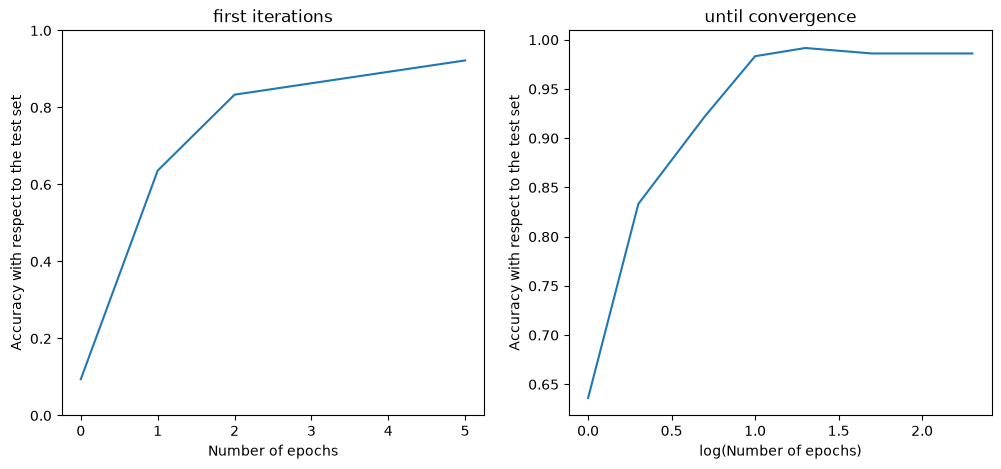

In [16]:
MaxIters = np.array([0, 1, 2, 5, 10, 20, 50, 100, 200])
accuracies = []

for it in MaxIters:
    my_classifier = svm.SVC(gamma=0.001, max_iter=it)
    my_classifier.fit(X_train, y_train)
    predicted = my_classifier.predict(X_test)
    acc = metrics.accuracy_score(y_test, predicted)
    accuracies.append(acc)

print("max_epoch", "accuracy")
for mi, ac in zip(MaxIters, accuracies):
    print(mi, ac)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
axes[0].set_title("first iterations")
axes[1].set_title("until convergence")
axes[0].plot(MaxIters[:4], accuracies[:4])
axes[1].plot(np.log10(MaxIters[1:]), accuracies[1:])
axes[0].set_xlabel("Number of epochs")
axes[1].set_xlabel("log(Number of epochs)")
axes[0].set_ylim(0, 1)
for ax in axes:
    ax.set_ylabel("Accuracy with respect to the test set")

One can also investigate how the performance differs when using more or less data.

Text(0.5, 1.0, 'Learning Curve for SVC')

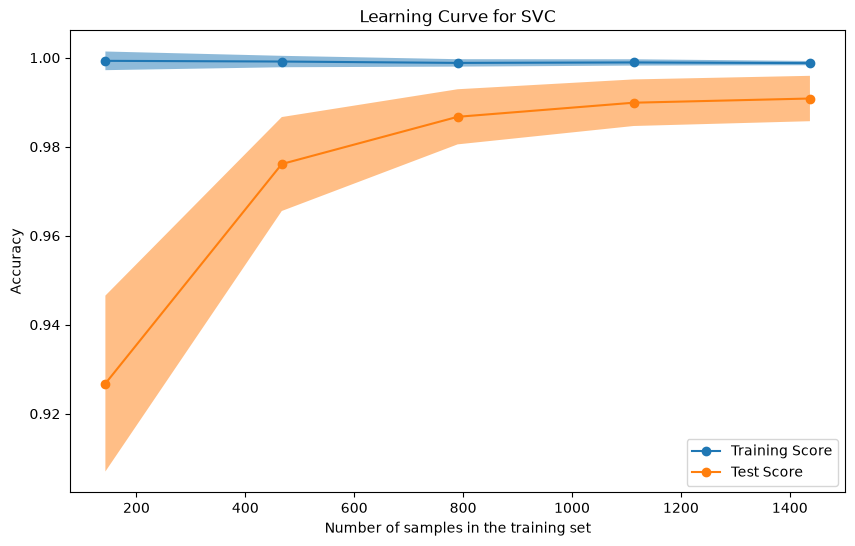

In [17]:
from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

# start from untrained model again
my_classifier = svm.SVC(kernel="rbf", gamma=0.001)

common_params = {
    "X": np.concatenate((X_train, X_test), axis=0),
    "y": np.concatenate((y_train, y_test), axis=0),
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": ShuffleSplit(n_splits=50, test_size=0.2, random_state=0),
    "score_type": "both",
    "n_jobs": 4,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "Accuracy",
}

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6), sharey=True)
LearningCurveDisplay.from_estimator(my_classifier, **common_params, ax=ax)
handles, label = ax.get_legend_handles_labels()
ax.legend(handles[:2], ["Training Score", "Test Score"])
ax.set_title(f"Learning Curve for {my_classifier.__class__.__name__}")

### Comparison between classifier models

Now one can start comparing the performance between different models, as e.g. done here with a naive Bayes classifier:

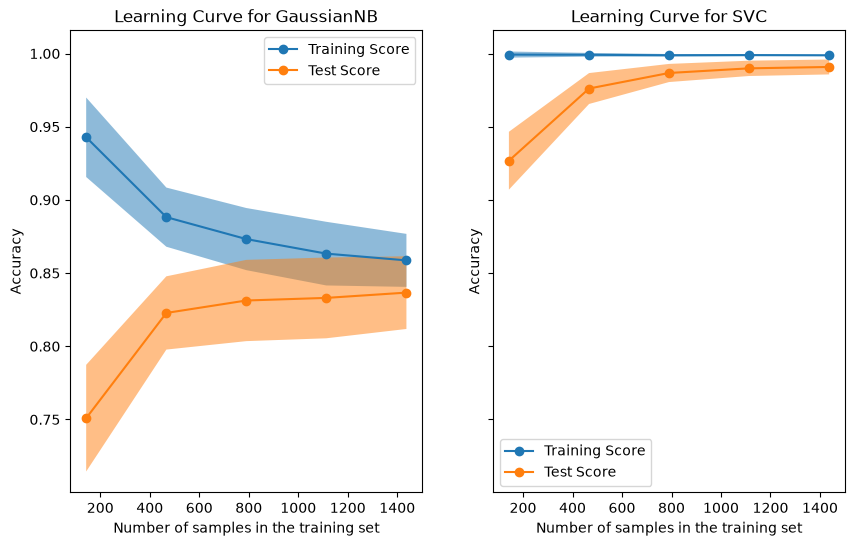

In [18]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6), sharey=True)

for ax_idx, estimator in enumerate([naive_bayes, my_classifier]):
    LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax[ax_idx])
    handles, label = ax[ax_idx].get_legend_handles_labels()
    ax[ax_idx].legend(handles[:2], ["Training Score", "Test Score"])
    ax[ax_idx].set_title(f"Learning Curve for {estimator.__class__.__name__}")

## Additional material

In order to make an educated decision on which model to pick, you should read through additional material, starting with [very short summaries](https://www.coursera.org/articles/machine-learning-algorithms). YouTube also offers comprehensive introductions, like the one from scikit-learn itself.

In [19]:
from IPython.display import YouTubeVideo

YouTubeVideo("playlist?list=PL2okA_2qDJ-m44KooOI7x8tu85wr4ez4f")

You can also use ChatGPT to get familiar with which machine learning solution fits your kind of problem considering the data and computational resources you have at hand. You should also watch out for comparisons between models like [this](https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html#sphx-glr-auto-examples-classification-plot-classifier-comparison-py), to get a glimpse of how the numerical trends differ between the methods.